In [1]:
# Note: need ipympl for this to work
%matplotlib widget
import numpy as np
from pathlib import Path
import nrrd  # Note: need pynrrd for this to work
import json

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.widgets import Slider

In [2]:
# Load data
root_path = Path(
    "/Users/clairenastaskin/data/2025-10-07/20251007-100747-butterfly_3d_v2/[2025-10-07 10.07.47]"
)
is_highres = True  # you probably want that

# Compute mode path
mode_idx = 0
mode_path = root_path / f"mode{mode_idx}_BMode"

# Load preset parameters
preset_params_name = (
    "preset_params.json" if not is_highres else "preset_params_highres.json"
)
preset_params_path = mode_path / preset_params_name
with open(preset_params_path) as file_handle:
    preset_params = json.load(file_handle)

In [3]:
# Load 3D data
# Note: Butterfly exports 3D volumes as NRRD files (basically a 3D numpy array + some metadata)
volume_output_name = "volume_highres" if is_highres else "volume"
volume_output_path = mode_path / (volume_output_name + ".nrrd")
vol_nrrd = nrrd.read(filename=volume_output_path.as_posix())

# Load corresponding JSON
# Note: should be useful to create a NIfTI file
volume_json_path = mode_path / (volume_output_name + ".nrrd.json")
with open(volume_json_path) as f:
    volume_metadata = json.load(f)
print(volume_metadata)

# Extract volume data and FOV parameters
vol = vol_nrrd[0]
volume_fov = preset_params["universal_params"]["volume_fov"]["fov"]
print(volume_fov)

{'dx_vol': 0.000313315926893, 'dy_vol': 0.000313315926893, 'dz_vol': 0.000293542074364, 'nx_vol': 384, 'ny_vol': 384, 'nz_vol': 512}
[0.0, 0.15, -0.06, 0.06, -0.06, 0.06, 0.000293542074364, 0.000313315926893, 0.000313315926893, 512, 384, 384, 512, 410, 410, 0.000293542074364, 0.0002933985330073, 0.0002933985330073, 0.0, 0]


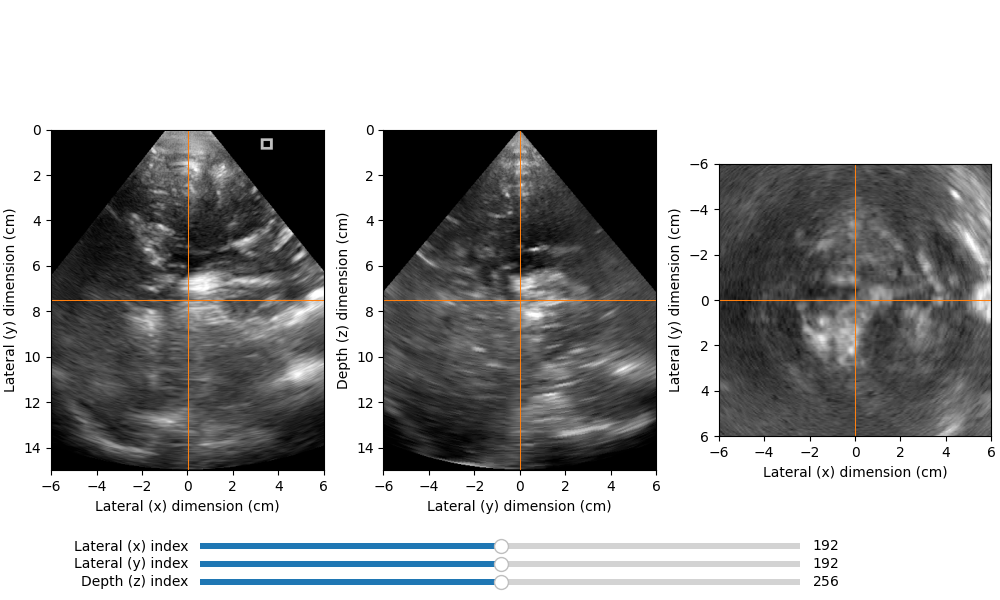

In [4]:
# Interactive display (slider) of 3D volume
axis_scale = 1e2  # Scale as cm

# Extract FOV parameters from Butterfly's metadata
vol_start_z = volume_fov[0]
vol_stop_z = volume_fov[1]
vol_start_x = volume_fov[2]
vol_stop_x = volume_fov[3]
vol_start_y = volume_fov[4]
vol_stop_y = volume_fov[5]

# Compute spans for each dimension
x_span = np.linspace(vol_start_x, vol_stop_x, vol.shape[1]) * axis_scale
y_span = np.linspace(vol_start_y, vol_stop_y, vol.shape[0]) * axis_scale
z_span = np.linspace(vol_start_z, vol_stop_z, vol.shape[2]) * axis_scale

# Plot properties
bmode_kwargs = {"cmap": "gray", "vmin": np.min(vol), "vmax": np.max(vol)}
slider_line_kwargs = {"color": "C1", "linewidth": 0.75}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(10, 6),
    layout="constrained",
)

fig: Figure
ax1: Axes = axes[0]
ax2: Axes = axes[1]
ax3: Axes = axes[2]

# Initial indices
init_x = vol.shape[0] // 2
init_y = vol.shape[1] // 2
init_z = vol.shape[2] // 2

# Initial images and crosshairs
im1 = ax1.imshow(
    vol[:, init_y, :].T,
    extent=(x_span[0], x_span[-1], z_span[-1], z_span[0]),
    **bmode_kwargs,
)
vline1 = ax1.axvline(x_span[init_x], **slider_line_kwargs)
hline1 = ax1.axhline(z_span[init_z], **slider_line_kwargs)

im2 = ax2.imshow(
    vol[init_x, :, :].T,
    extent=(y_span[0], y_span[-1], z_span[-1], z_span[0]),
    **bmode_kwargs,
)
vline2 = ax2.axvline(y_span[init_y], **slider_line_kwargs)
hline2 = ax2.axhline(z_span[init_z], **slider_line_kwargs)

im3 = ax3.imshow(
    vol[:, :, init_z].T,
    extent=(x_span[0], x_span[-1], y_span[-1], y_span[0]),
    **bmode_kwargs,
)
vline3 = ax3.axvline(x_span[init_x], **slider_line_kwargs)
hline3 = ax3.axhline(y_span[init_y], **slider_line_kwargs)

# Axes labels
lateral_x_label = "Lateral (x) dimension (cm)"
lateral_y_label = "Lateral (y) dimension (cm)"
depth_z_label = "Depth (z) dimension (cm)"
ax1.set_xlabel(lateral_x_label)
ax1.set_ylabel(lateral_y_label)
ax2.set_xlabel(lateral_y_label)
ax2.set_ylabel(depth_z_label)
ax3.set_xlabel(lateral_x_label)
ax3.set_ylabel(lateral_y_label)

# Create slider axes
ax_x = plt.axes([0.2, 0.08, 0.6, 0.02])
ax_y = plt.axes([0.2, 0.05, 0.6, 0.02])
ax_z = plt.axes([0.2, 0.02, 0.6, 0.02])

# Create sliders
slider_x = Slider(
    ax_x, "Lateral (x) index", 0, vol.shape[0] - 1, valinit=init_x, valstep=1
)
slider_y = Slider(
    ax_y, "Lateral (y) index", 0, vol.shape[1] - 1, valinit=init_y, valstep=1
)
slider_z = Slider(
    ax_z, "Depth (z) index", 0, vol.shape[2] - 1, valinit=init_z, valstep=1
)


# Update function
def update(val):
    x = int(slider_x.val)
    y = int(slider_y.val)
    z = int(slider_z.val)

    # Update images
    im1.set_data(vol[:, y, :].T)
    im2.set_data(vol[x, :, :].T)
    im3.set_data(vol[:, :, z].T)

    # Update crosshairs
    vline1.set_xdata([x_span[x], x_span[x]])
    hline1.set_ydata([z_span[z], z_span[z]])

    vline2.set_xdata([y_span[y], y_span[y]])
    hline2.set_ydata([z_span[z], z_span[z]])

    vline3.set_xdata([x_span[x], x_span[x]])
    hline3.set_ydata([y_span[y], y_span[y]])

    fig.canvas.draw_idle()


# Connect sliders
slider_x.on_changed(update)
slider_y.on_changed(update)
slider_z.on_changed(update)

plt.show()

In [5]:
######################
# Corresponding fUSI data #
######################

import nibabel as nib
import numpy as np
from pathlib import Path
import tqdm
import matplotlib.pyplot as plt
import os

# Define the base path where your NIfTI files are stored
base_path = Path('/Users/clairenastaskin/data/2025-10-07/fUSI/')  
pwd_file_name = 'sub-Forest001_ses-20251007_task-LGN_run-004_pwd.nii.gz'

pwd_path = base_path / pwd_file_name

# Load fUSI nifti file and get data into a numpy array
nifti_img = nib.load(pwd_path)
fusi_data = nifti_img.get_fdata()
fusi_data[np.isnan(fusi_data)] = 0 # set nan to 0
affine_fUSI = nifti_img.affine
print(fusi_data.shape)
fusi_data_mean = np.mean(fusi_data,-1)
# save fusi_data_mean as nifti file
nifti_mean = nib.Nifti1Image(fusi_data_mean, affine_fUSI)
nib.save(nifti_mean, base_path / 'fusi_data_mean.nii.gz')

print("Affine matrix for fUSI:")
print(affine_fUSI)

(168, 81, 140, 244)
Affine matrix for fUSI:
[[  0.616        0.           0.         -51.74399948]
 [  0.          -0.616        0.          24.94799995]
 [  0.           0.          -0.616      -20.90731621]
 [  0.           0.           0.           1.        ]]


In [8]:
# Create affine matrix for vol that matches affine_fUSI's orientation and center
# but uses vol's voxel sizes

# Extract voxel sizes from volume_metadata (convert from meters to mm)
dx_vol_mm = volume_metadata['dx_vol'] * 1000  # Convert m to mm
dy_vol_mm = volume_metadata['dy_vol'] * 1000  # Convert m to mm
dz_vol_mm = volume_metadata['dz_vol'] * 1000  # Convert m to mm

# Extract translation from affine_fUSI (last column, first 3 rows)
translation = affine_fUSI[:3, 3]

# Create affine matrix with same orientation as affine_fUSI (x positive, y negative, z negative)
# but with vol's voxel sizes
affine_vol = np.eye(4)
affine_vol[0, 0] = dx_vol_mm   # x: positive
# affine_vol[1, 1] = -dy_vol_mm  # y: negative (to match affine_fUSI)
# affine_vol[2, 2] = -dz_vol_mm  # z: negative (to match affine_fUSI)
affine_vol[1, 1] = dy_vol_mm  # y: positive 
affine_vol[2, 2] = dz_vol_mm  # z: positive 
affine_vol[:3, 3] = translation  # Same translation as affine_fUSI

print("Affine matrix for vol:")
print(affine_vol)
print(f"\nVoxel sizes (mm): dx={dx_vol_mm:.6f}, dy={dy_vol_mm:.6f}, dz={dz_vol_mm:.6f}")
print(f"Translation (mm): {translation}")


Affine matrix for vol:
[[  0.31331593   0.           0.         -51.74399948]
 [  0.           0.31331593   0.          24.94799995]
 [  0.           0.           0.29354207 -20.90731621]
 [  0.           0.           0.           1.        ]]

Voxel sizes (mm): dx=0.313316, dy=0.313316, dz=0.293542
Translation (mm): [-51.74399948  24.94799995 -20.90731621]


In [9]:
# Save vol as a NIfTI file using affine_vol

import nibabel as nib
import numpy as np

vol_cropped = vol[:, :, 0:280]
# Save vol as a NIfTI file in root_path
nifti_path = root_path / "volume.nii.gz"
nifti_path_cropped = root_path / "volume_cropped.nii.gz"


nifti_img = nib.Nifti1Image(vol.astype(np.float32), affine=affine_vol)
nifti_img_cropped = nib.Nifti1Image(vol_cropped.astype(np.float32), affine=affine_vol)

nib.save(nifti_img, nifti_path)
nib.save(nifti_img_cropped, nifti_path_cropped)


print(f"NIfTI file saved to {nifti_path}")
print(f"NIfTI file saved to {nifti_path_cropped}")


NIfTI file saved to /Users/clairenastaskin/data/2025-10-07/20251007-100747-butterfly_3d_v2/[2025-10-07 10.07.47]/volume.nii.gz
NIfTI file saved to /Users/clairenastaskin/data/2025-10-07/20251007-100747-butterfly_3d_v2/[2025-10-07 10.07.47]/volume_cropped.nii.gz
